# 04 — Modelos de Deep Learning

**Reto 2 — IA avanzada en Business Analytics | Odisea Data**

**Objetivo:** Implementar redes neuronales profundas con TensorFlow/Keras y comparar con los modelos de ML clásico del notebook 03.

**Arquitecturas a probar:**
1. **MLP básico** (baseline): 2 capas densas.
2. **MLP profundo** con Dropout + BatchNormalization.

**Estrategia contra el desbalanceo:**
- `class_weight` calculado a partir de la distribución de clases.
- EarlyStopping + ReduceLROnPlateau para evitar overfitting.

In [1]:
# ============================================================
# SETUP COLAB: carpetas + descarga de datos
# ============================================================
import os
from google.colab import files

# 1. Crear carpetas
for c in ["outputs/charts", "outputs/metrics", "models/trained", "models/scalers"]:
    os.makedirs(c, exist_ok=True)
print("✅ Carpetas creadas")

# 2. Verificar archivos necesarios
archivos_necesarios = ["train_processed.csv", "test_processed.csv"]
faltantes = [f for f in archivos_necesarios if not os.path.exists(f)]

if faltantes:
    print(f"⚠️  Faltan: {faltantes}. Subiéndolos...")
    files.upload()
else:
    print("✅ Todos los archivos necesarios presentes")

✅ Carpetas creadas
⚠️  Faltan: ['train_processed.csv', 'test_processed.csv']. Subiéndolos...


Saving test_processed.csv to test_processed.csv
Saving train_processed.csv to train_processed.csv


In [2]:
# ============================================================
# SETUP COLAB: carpetas + archivos necesarios
# ============================================================
import os
from google.colab import files

for c in ["outputs/charts", "outputs/metrics", "models/trained"]:
    os.makedirs(c, exist_ok=True)
print("✅ Carpetas creadas")

archivos_necesarios = ["train_processed.csv", "test_processed.csv"]
faltantes = [f for f in archivos_necesarios if not os.path.exists(f)]

if faltantes:
    print(f"⚠️  Faltan: {faltantes}. Subiéndolos...")
    files.upload()
else:
    print("✅ Todos los archivos presentes")

✅ Carpetas creadas
✅ Todos los archivos presentes


In [3]:
# ============================================================
# IMPORTS Y CONFIGURACIÓN
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"✅ TensorFlow: {tf.__version__}")
print(f"🖥️  GPU disponible: {tf.config.list_physical_devices('GPU')}")

✅ TensorFlow: 2.20.0
🖥️  GPU disponible: []


In [4]:
# ============================================================
# CARGA DE DATOS PROCESADOS
# ============================================================
train = pd.read_csv("train_processed.csv")
test = pd.read_csv("test_processed.csv")

X_train = train.drop(columns=["Response"]).values
y_train = train["Response"].values
X_test = test.drop(columns=["Response"]).values
y_test = test["Response"].values

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nDistribución de y_train: {dict(zip(*np.unique(y_train, return_counts=True)))}")

X_train: (304887, 10)
X_test:  (76222, 10)

Distribución de y_train: {np.int64(0): np.int64(267519), np.int64(1): np.int64(37368)}


In [5]:
# ============================================================
# CLASS WEIGHT (para desbalanceo)
# ============================================================
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train,
)
class_weights = dict(enumerate(class_weights_array))

print(f"⚖️  Class weights: {class_weights}")
print(f"   Clase 0 (no interesado) → peso {class_weights[0]:.2f}")
print(f"   Clase 1 (interesado)    → peso {class_weights[1]:.2f}")

⚖️  Class weights: {0: np.float64(0.5698417682482366), 1: np.float64(4.079519910083494)}
   Clase 0 (no interesado) → peso 0.57
   Clase 1 (interesado)    → peso 4.08


In [6]:
# ============================================================
# MODELO 1: MLP BÁSICO (baseline)
# ============================================================
def build_mlp_basic(input_dim):
    model = Sequential([
        Dense(64, activation="relu", input_shape=(input_dim,)),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid"),
    ], name="MLP_basico")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")],
    )
    return model

model_1 = build_mlp_basic(X_train.shape[1])
model_1.summary()

Model: "MLP_basico"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ============================================================
# MODELO 2: MLP PROFUNDO con Dropout y BatchNormalization
# ============================================================
def build_mlp_deep(input_dim):
    model = Sequential([
        # Bloque 1
        Dense(128, activation="relu", input_shape=(input_dim,),
              kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(),
        Dropout(0.3),

        # Bloque 2
        Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(),
        Dropout(0.3),

        # Bloque 3
        Dense(32, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),

        # Salida
        Dense(1, activation="sigmoid"),
    ], name="MLP_profundo")
    model.compile(
        optimizer=Adam(learning_rate=5e-4),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")],
    )
    return model

model_2 = build_mlp_deep(X_train.shape[1])
model_2.summary()

Model: "MLP_profundo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,673 (49.50 KB)

 Trainable params: 12,225 (47.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
# ============================================================
# CALLBACKS
# ============================================================
def get_callbacks():
    return [
        callbacks.EarlyStopping(
            monitor="val_auc", mode="max",
            patience=8, restore_best_weights=True, verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=4, min_lr=1e-6, verbose=1,
        ),
    ]

In [9]:
# ============================================================
# ENTRENAMIENTO MODELO 1
# ============================================================
EPOCHS = 50
BATCH_SIZE = 512

print("🚀 Entrenando MLP básico...")
t0 = time.time()

history_1 = model_1.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=get_callbacks(),
    verbose=1,
)

print(f"\n⏱️  Tiempo: {time.time()-t0:.1f}s")
print(f"🏁 Épocas ejecutadas: {len(history_1.history['loss'])}")

🚀 Entrenando MLP básico...
Epoch 1/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5037 - auc: 0.5059 - loss: 41.4258 - val_accuracy: 0.8757 - val_auc: 0.5032 - val_loss: 24.7281 - learning_rate: 0.0010
Epoch 2/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5238 - auc: 0.5177 - loss: 32.1383 - val_accuracy: 0.8186 - val_auc: 0.5566 - val_loss: 1.9085 - learning_rate: 0.0010
Epoch 3/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5222 - auc: 0.5271 - loss: 27.4183 - val_accuracy: 0.6850 - val_auc: 0.6591 - val_loss: 2.7829 - learning_rate: 0.0010
Epoch 4/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5482 - auc: 0.5556 - loss: 19.1739 - val_accuracy: 0.1866 - val_auc: 0.5284 - val_loss: 25.3024 - learning_rate: 0.0010
Epoch 5/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5550 - auc: 0.5589 - loss: 17.9156 - val_accuracy: 0.2068 - val_auc: 0.5553 - val_loss: 23.8287 - learning_rate: 0.0010
Epoch 6/50
496/507 ━━━━━━━━━━━━━━━━━━━━ 0s 3m

In [10]:
# ============================================================
# ENTRENAMIENTO MODELO 2
# ============================================================
print("🚀 Entrenando MLP profundo...")
t0 = time.time()

history_2 = model_2.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=get_callbacks(),
    verbose=1,
)

print(f"\n⏱️  Tiempo: {time.time()-t0:.1f}s")
print(f"🏁 Épocas ejecutadas: {len(history_2.history['loss'])}")

🚀 Entrenando MLP profundo...
Epoch 1/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.5494 - auc: 0.5624 - loss: 0.7447 - val_accuracy: 0.1984 - val_auc: 0.6388 - val_loss: 0.8340 - learning_rate: 5.0000e-04
Epoch 2/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.5498 - auc: 0.6092 - loss: 0.6870 - val_accuracy: 0.1238 - val_auc: 0.5687 - val_loss: 0.8532 - learning_rate: 5.0000e-04
Epoch 3/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.5262 - auc: 0.6427 - loss: 0.6602 - val_accuracy: 0.6618 - val_auc: 0.6247 - val_loss: 0.4956 - learning_rate: 5.0000e-04
Epoch 4/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5118 - auc: 0.6483 - loss: 0.6517 - val_accuracy: 0.1423 - val_auc: 0.6650 - val_loss: 0.8094 - learning_rate: 5.0000e-04
Epoch 5/50
507/507 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5326 - auc: 0.6373 - loss: 0.6619 - val_accuracy: 0.1444 - val_auc: 0.6467 - val_loss: 0.7804 - learning_rate: 5.0000e-04
Epoch 6/50
507/507 ━━━━━━

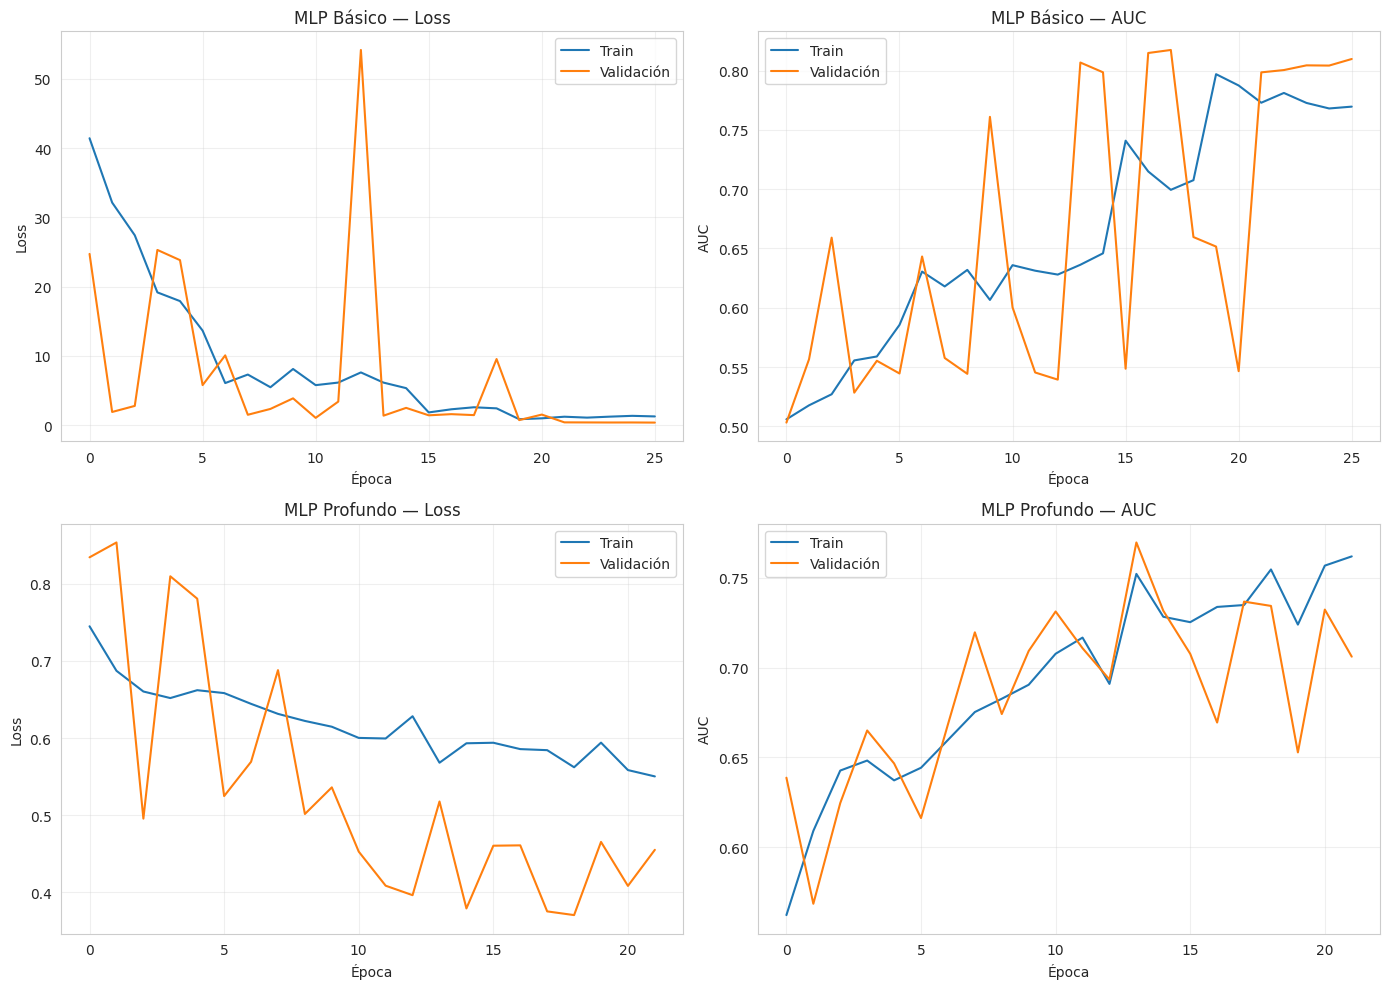

In [11]:
# ============================================================
# CURVAS DE ENTRENAMIENTO
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (hist, nombre) in enumerate([(history_1, "MLP Básico"), (history_2, "MLP Profundo")]):
    # Loss
    axes[i, 0].plot(hist.history["loss"], label="Train")
    axes[i, 0].plot(hist.history["val_loss"], label="Validación")
    axes[i, 0].set_title(f"{nombre} — Loss")
    axes[i, 0].set_xlabel("Época")
    axes[i, 0].set_ylabel("Loss")
    axes[i, 0].legend()
    axes[i, 0].grid(alpha=0.3)

    # AUC
    axes[i, 1].plot(hist.history["auc"], label="Train")
    axes[i, 1].plot(hist.history["val_auc"], label="Validación")
    axes[i, 1].set_title(f"{nombre} — AUC")
    axes[i, 1].set_xlabel("Época")
    axes[i, 1].set_ylabel("AUC")
    axes[i, 1].legend()
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/charts/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# ============================================================
# EVALUACIÓN EN TEST
# ============================================================
def evaluar_modelo(modelo, X_test, y_test, nombre):
    y_proba = modelo.predict(X_test, verbose=0).ravel()
    y_pred = (y_proba >= 0.5).astype(int)

    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_proba),
    }

resultados_dl = [
    evaluar_modelo(model_1, X_test, y_test, "MLP Básico"),
    evaluar_modelo(model_2, X_test, y_test, "MLP Profundo"),
]

df_dl = pd.DataFrame(resultados_dl)
print("="*60)
print("📊 RESULTADOS DEEP LEARNING")
print("="*60)
print(df_dl.to_string(index=False))

📊 RESULTADOS DEEP LEARNING
      Modelo  Accuracy  Precision   Recall       F1  AUC-ROC
  MLP Básico  0.635381   0.246538 0.960501 0.392365 0.819732
MLP Profundo  0.675684   0.241980 0.771890 0.368453 0.770490


In [14]:
# ============================================================
# SUBIR ARTEFACTOS DEL NOTEBOOK 03
# ============================================================
import os
from google.colab import files

archivos_03 = [
    "outputs/metrics/metricas_modelos.csv",
    "models/trained/random_forest.pkl",
    "models/trained/xgboost.pkl",
    "models/trained/lightgbm.pkl",
]

faltantes = [a for a in archivos_03 if not os.path.exists(a)]

if faltantes:
    print(f"⚠️  Faltan {len(faltantes)} archivos del notebook 03.")
    print("Sube los siguientes (puedes seleccionarlos todos a la vez con Ctrl):")
    for f in faltantes:
        print(f"   - {f.split('/')[-1]}")
    uploaded = files.upload()
    print("✅ Archivos subidos:", list(uploaded.keys()))
else:
    print("✅ Todos los archivos presentes")

⚠️  Faltan 4 archivos del notebook 03.
Sube los siguientes (puedes seleccionarlos todos a la vez con Ctrl):
   - metricas_modelos.csv
   - random_forest.pkl
   - xgboost.pkl
   - lightgbm.pkl


Saving metricas_modelos.csv to metricas_modelos.csv
✅ Archivos subidos: ['metricas_modelos.csv']


In [15]:
# ============================================================
# SUBIR ARTEFACTOS DEL NOTEBOOK 03
# ============================================================
import os
from google.colab import files

archivos_03 = [
    "outputs/metrics/metricas_modelos.csv",
    "models/trained/random_forest.pkl",
    "models/trained/xgboost.pkl",
    "models/trained/lightgbm.pkl",
]

faltantes = [a for a in archivos_03 if not os.path.exists(a)]

if faltantes:
    print(f"⚠️  Faltan {len(faltantes)} archivos del notebook 03.")
    print("Sube los siguientes (puedes seleccionarlos todos a la vez con Ctrl):")
    for f in faltantes:
        print(f"   - {f.split('/')[-1]}")
    uploaded = files.upload()
    print("✅ Archivos subidos:", list(uploaded.keys()))
else:
    print("✅ Todos los archivos presentes")

⚠️  Faltan 4 archivos del notebook 03.
Sube los siguientes (puedes seleccionarlos todos a la vez con Ctrl):
   - metricas_modelos.csv
   - random_forest.pkl
   - xgboost.pkl
   - lightgbm.pkl


Saving lightgbm.pkl to lightgbm.pkl
Saving random_forest.pkl to random_forest.pkl
Saving xgboost.pkl to xgboost.pkl
✅ Archivos subidos: ['lightgbm.pkl', 'random_forest.pkl', 'xgboost.pkl']


In [16]:
# Mover a sus carpetas correctas
import shutil

movimientos = {
    "metricas_modelos.csv": "outputs/metrics/metricas_modelos.csv",
    "random_forest.pkl": "models/trained/random_forest.pkl",
    "xgboost.pkl": "models/trained/xgboost.pkl",
    "lightgbm.pkl": "models/trained/lightgbm.pkl",
}

for origen, destino in movimientos.items():
    if os.path.exists(origen) and origen != destino:
        shutil.move(origen, destino)
        print(f"✅ {origen} → {destino}")

print("\n📂 Verificación:")
for a in archivos_03:
    estado = "✅" if os.path.exists(a) else "❌"
    print(f"  {estado} {a}")

✅ metricas_modelos.csv → outputs/metrics/metricas_modelos.csv
✅ random_forest.pkl → models/trained/random_forest.pkl
✅ xgboost.pkl → models/trained/xgboost.pkl
✅ lightgbm.pkl → models/trained/lightgbm.pkl

📂 Verificación:
  ✅ outputs/metrics/metricas_modelos.csv
  ✅ models/trained/random_forest.pkl
  ✅ models/trained/xgboost.pkl
  ✅ models/trained/lightgbm.pkl


In [17]:
# ============================================================
# COMPARATIVA CON MODELOS ML CLÁSICO
# ============================================================
# Cargamos los resultados del notebook 03
df_ml = pd.read_csv("outputs/metrics/metricas_modelos.csv")

# Unificamos
df_comparativa = pd.concat([
    df_ml[["Modelo", "Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]],
    df_dl[["Modelo", "Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]],
], ignore_index=True).sort_values("AUC-ROC", ascending=False)

print("="*60)
print("🏆 COMPARATIVA FINAL — TODOS LOS MODELOS")
print("="*60)
print(df_comparativa.to_string(index=False))

# Guardar
df_comparativa.to_csv("outputs/metrics/comparativa_final.csv", index=False)

🏆 COMPARATIVA FINAL — TODOS LOS MODELOS
             Modelo  Accuracy  Precision   Recall       F1  AUC-ROC
           LightGBM  0.713114   0.288350 0.913295 0.438314 0.857443
            XGBoost  0.716447   0.290175 0.908264 0.439831 0.856800
      Random Forest  0.711041   0.286431 0.910405 0.435763 0.856130
Logistic Regression  0.639054   0.250549 0.976772 0.398802 0.833648
         MLP Básico  0.635381   0.246538 0.960501 0.392365 0.819732
       MLP Profundo  0.675684   0.241980 0.771890 0.368453 0.770490


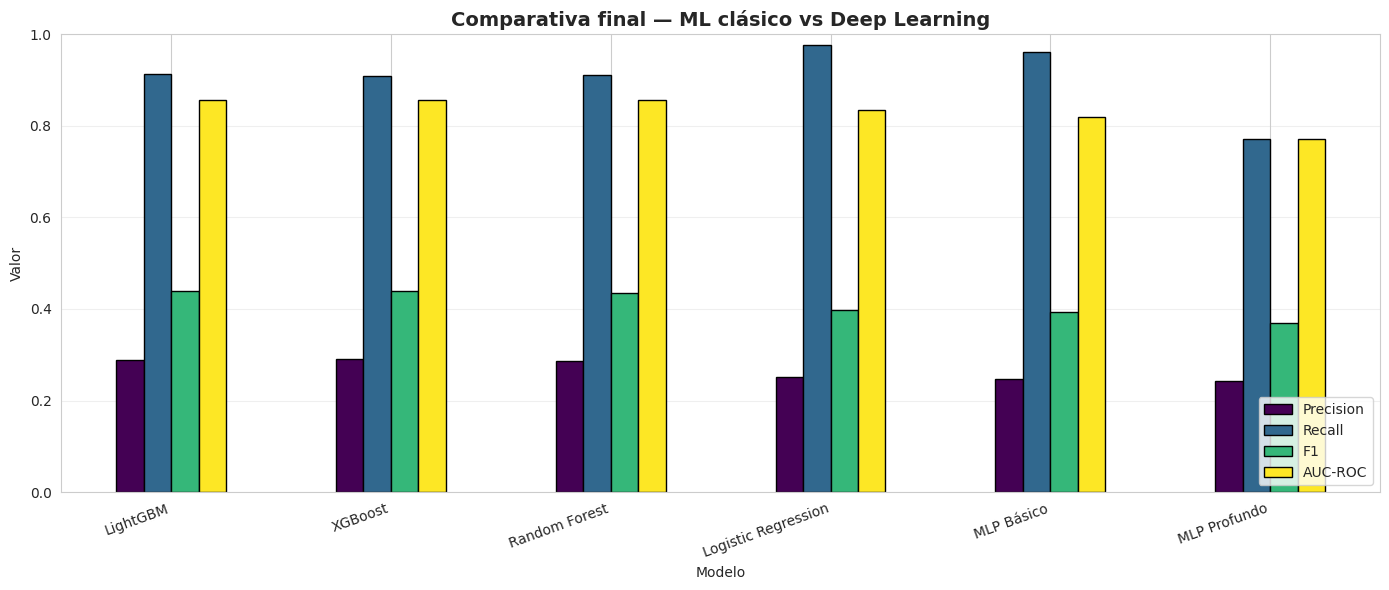

In [18]:
# ============================================================
# GRÁFICO COMPARATIVO FINAL
# ============================================================
metricas_plot = ["Precision", "Recall", "F1", "AUC-ROC"]

fig, ax = plt.subplots(figsize=(14, 6))
df_plot = df_comparativa.set_index("Modelo")[metricas_plot]
df_plot.plot(kind="bar", ax=ax, colormap="viridis", edgecolor="black")

ax.set_title("Comparativa final — ML clásico vs Deep Learning",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.savefig("outputs/charts/comparativa_final.png", dpi=150, bbox_inches="tight")
plt.show()

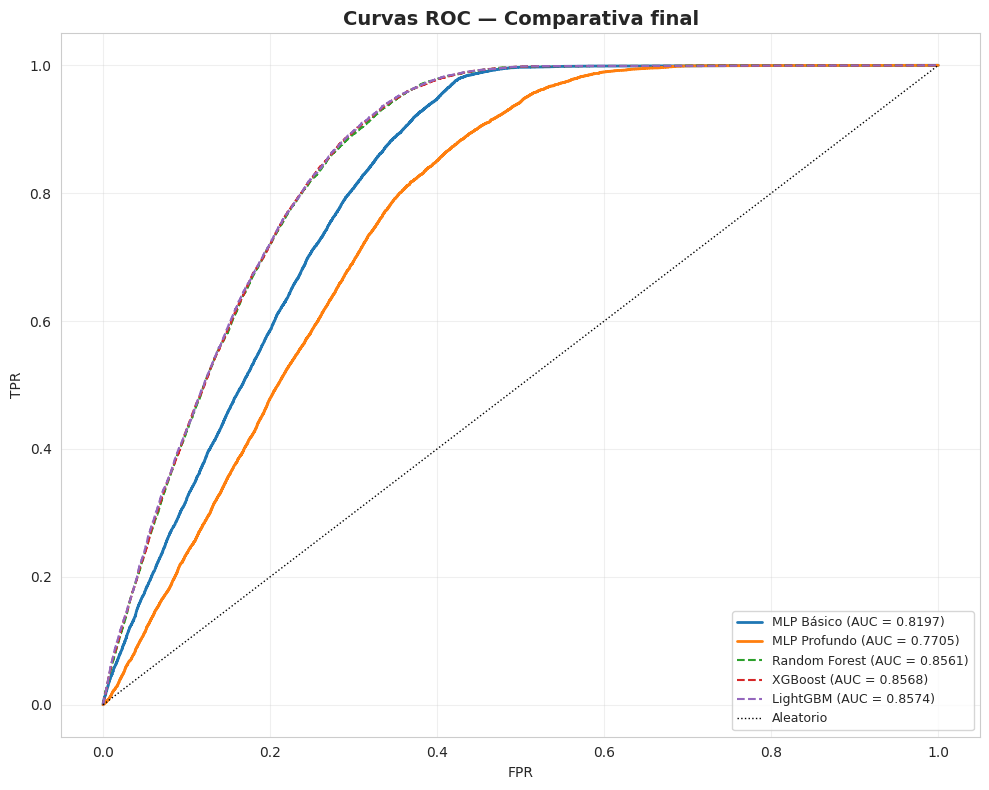

In [19]:
# ============================================================
# CURVAS ROC — ML clásico + Deep Learning
# ============================================================
plt.figure(figsize=(10, 8))

# Modelos DL
for modelo, nombre in [(model_1, "MLP Básico"), (model_2, "MLP Profundo")]:
    y_proba = modelo.predict(X_test, verbose=0).ravel()
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.4f})", linewidth=2)

# Cargar modelos ML clásicos
import joblib
modelos_ml = {
    "Random Forest": "models/trained/random_forest.pkl",
    "XGBoost": "models/trained/xgboost.pkl",
    "LightGBM": "models/trained/lightgbm.pkl",
}
for nombre, ruta in modelos_ml.items():
    if os.path.exists(ruta):
        m = joblib.load(ruta)
        y_proba = m.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{nombre} (AUC = {auc:.4f})",
                 linewidth=1.5, linestyle="--")

plt.plot([0, 1], [0, 1], "k:", linewidth=1, label="Aleatorio")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curvas ROC — Comparativa final", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/charts/roc_curves_final.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# ============================================================
# GUARDAR MODELOS DL
# ============================================================
model_1.save("models/trained/mlp_basico.keras")
model_2.save("models/trained/mlp_profundo.keras")
print("✅ Modelos guardados en models/trained/")

✅ Modelos guardados en models/trained/


In [21]:
# ============================================================
# DESCARGAR ARTEFACTOS
# ============================================================
import zipfile
from google.colab import files

archivos = [
    "outputs/metrics/comparativa_final.csv",
    "outputs/charts/training_curves.png",
    "outputs/charts/comparativa_final.png",
    "outputs/charts/roc_curves_final.png",
    "models/trained/mlp_basico.keras",
    "models/trained/mlp_profundo.keras",
]

with zipfile.ZipFile("deep_learning_artefactos.zip", "w") as zipf:
    for a in archivos:
        if os.path.exists(a):
            zipf.write(a)
            print(f"✅ {a}")
        else:
            print(f"⚠️  NO encontrado: {a}")

files.download("deep_learning_artefactos.zip")

✅ outputs/metrics/comparativa_final.csv
✅ outputs/charts/training_curves.png
✅ outputs/charts/comparativa_final.png
✅ outputs/charts/roc_curves_final.png
✅ models/trained/mlp_basico.keras
✅ models/trained/mlp_profundo.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🔍 Conclusiones — Deep Learning

### Arquitecturas implementadas
1. **MLP básico** (2 capas densas).
2. **MLP profundo** (3 bloques con Dropout + BatchNormalization + regularización L2).

### Estrategia contra el desbalanceo
- `class_weight` calculado con `compute_class_weight("balanced")`.
- Callbacks: EarlyStopping (patience=8) + ReduceLROnPlateau.

### Comparación con ML clásico
- Ver `outputs/metrics/comparativa_final.csv`.
- En datasets tabulares como este, los modelos basados en árboles (XGBoost, LightGBM) suelen rendir igual o mejor que las redes neuronales.
- El Deep Learning brilla cuando hay:
  - Grandes volúmenes de datos.
  - Variables no estructuradas (imágenes, texto).
  - Patrones complejos no lineales.

### Próximos pasos
- **Notebook 05**: Interpretabilidad con SHAP + conclusiones de negocio + recomendaciones.
- **Informe final**: `reports/informe_analisis.md`.
- **Presentación**: `presentation/`.